# Epoch-wise Analysis: PairMixer 12M (toymix_dti_esmc_v2)

Probes how molecular embeddings and ADMET downstream transfer evolve across saved pretraining checkpoints (epochs 20/40/60/80/100).

**Motivation:** earlier checkpoints (epoch 20) appear to transfer better to ADMET than the fully-trained (epoch 100) backbone. This notebook quantifies the drift.

**Sections:**
1. SMILES probe — extract GNN + graph embeddings for a fixed set of molecules across epochs
2. Representation drift — pairwise linear CKA between epochs + PCA scatter
3. ADMET downstream — per-epoch 22-task metrics from `experiment_results.csv`

In [1]:
import os

# ── GPU selection ────────────────────────────────────────────────────────────
# Set which CUDA device the whole notebook uses. Must be configured BEFORE torch
# touches CUDA, so keep this at the top of cell-1.
GPU_ID = 7

os.environ["CUDA_VISIBLE_DEVICES"] = str(GPU_ID)

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

matplotlib.rcParams.update({"font.size": 11, "figure.dpi": 120})
sns.set_style("whitegrid")

REPO = Path.cwd().parent
sys.path.insert(0, str(REPO))
sys.path.insert(0, str(REPO / "notebooks"))

from notebook_utils import ADMET_TASK_ORDER as TASK_ORDER, TASK_CATEGORY, TASK_METRICS

CATEGORY_COLORS = {
    "Absorption": "#4C72B0", "Distribution": "#8172B2",
    "Metabolism": "#DD8452", "Excretion": "#55A868", "Toxicity": "#C44E52",
}

# CUDA_VISIBLE_DEVICES masks physical GPU GPU_ID as logical "cuda:0".
DEVICE = "cuda:0" if torch.cuda.is_available() else "cpu"
print(f"physical GPU {GPU_ID} -> torch sees {torch.cuda.device_count()} device(s); using {DEVICE}")
if torch.cuda.is_available():
    print(f"  {torch.cuda.get_device_name(0)}")


physical GPU 7 -> torch sees 1 device(s); using cuda:0
  NVIDIA RTX PRO 6000 Blackwell Max-Q Workstation Edition


In [2]:
# ── Per-epoch checkpoint registry ─────────────────────────────────────────────
CKPT_DIR = REPO / "models_checkpoints/toymix-dti-esmc-v2/pairmixer_12M/2026-04-18_11-23-58_20260418_112358"
CKPT_BY_EPOCH = {
    20:  CKPT_DIR / "toymix_dti_esmc_v2_pairmixer_12M_epochepoch=019_20260418_112358.ckpt",
    40:  CKPT_DIR / "toymix_dti_esmc_v2_pairmixer_12M_epochepoch=039_20260418_112358.ckpt",
    60:  CKPT_DIR / "toymix_dti_esmc_v2_pairmixer_12M_epochepoch=059_20260418_112358.ckpt",
    80:  CKPT_DIR / "toymix_dti_esmc_v2_pairmixer_12M_epochepoch=079_20260418_112358.ckpt",
    100: CKPT_DIR / "toymix_dti_esmc_v2_pairmixer_12M_epochepoch=099_20260418_112358.ckpt",
}
EPOCHS = sorted(CKPT_BY_EPOCH.keys())

for e, p in CKPT_BY_EPOCH.items():
    print(f"  epoch {e:3d}: {'OK' if p.exists() else 'MISSING':8s} {p.name}")

  epoch  20: OK       toymix_dti_esmc_v2_pairmixer_12M_epochepoch=019_20260418_112358.ckpt
  epoch  40: OK       toymix_dti_esmc_v2_pairmixer_12M_epochepoch=039_20260418_112358.ckpt
  epoch  60: OK       toymix_dti_esmc_v2_pairmixer_12M_epochepoch=059_20260418_112358.ckpt
  epoch  80: OK       toymix_dti_esmc_v2_pairmixer_12M_epochepoch=079_20260418_112358.ckpt
  epoch 100: OK       toymix_dti_esmc_v2_pairmixer_12M_epochepoch=099_20260418_112358.ckpt


## 1. SMILES probe

Featurize a fixed probe set once, then run each epoch's backbone on the same graphs.

In [3]:
from tqdm.auto import tqdm
from torch_geometric.data import Batch
from torch_geometric.nn import global_mean_pool

from graphium.features.featurizer import mol_to_pyggraph
from graphium.trainer.predictor import PredictorModule
import datamol as dm

# Probe set: Caco2 test split molecules (broadly varied drug-like; small enough for quick probe).
# Swap for any SMILES list you like.
from tdc.single_pred import ADME
_probe = ADME(name="Caco2_Wang").get_split()["test"]
PROBE_SMILES = _probe["Drug"].tolist()
print(f"probe size: {len(PROBE_SMILES)} SMILES")
PROBE_SMILES[:3]

Found local copy...
Loading...
Done!


probe size: 182 SMILES


['CC1(C)CNc2cc(NC(=O)c3cccnc3NCc3ccncc3)ccc21',
 'C/C=C(/C)C(=O)O[C@@H]([C@@H](O)c1cc2ccc(=O)oc2cc1OC)C(C)(C)O',
 'O=c1cc(-c2ccccc2)oc2ccccc12']

In [4]:
# Featurization must match pairmixer_12M's expanded RDKit feature set
# (see expts/hydra-configs/model/pairmixer_12M.yaml).
FEATURIZATION = {
    "atom_property_list_onehot": ["atomic-number", "group", "period", "total-valence", "hybridization", "chirality"],
    "atom_property_list_float": ["degree", "formal-charge", "radical-electron", "aromatic", "in-ring", "mass", "electronegativity", "vdw-radius", "num-ring"],
    "edge_property_list": ["bond-type-onehot", "stereo", "in-ring", "conjugated"],
    "add_self_loop": False,
    "explicit_H": False,
    "use_bonds_weights": False,
    "pos_encoding_as_features": {
        "pos_types": {
            "lap_eigvec": {"pos_level": "node", "pos_type": "laplacian_eigvec", "num_pos": 8, "normalization": "none", "disconnected_comp": True},
            "lap_eigval": {"pos_level": "node", "pos_type": "laplacian_eigval", "num_pos": 8, "normalization": "none", "disconnected_comp": True},
            "rw_pos":     {"pos_level": "node", "pos_type": "rw_return_probs", "ksteps": 16},
        }
    },
}

# Featurize once; graphs are reused across all epochs.
graphs = []
valid_smiles = []
for smi in tqdm(PROBE_SMILES, desc="featurize"):
    mol = dm.to_mol(smi)
    if mol is None:
        continue
    try:
        g = mol_to_pyggraph(mol, on_error="raise", **FEATURIZATION)
        graphs.append(g)
        valid_smiles.append(smi)
    except Exception:
        continue
print(f"featurized {len(graphs)}/{len(PROBE_SMILES)}")


featurize:   0%|          | 0/182 [00:00<?, ?it/s]

featurized 182/182


In [5]:
@torch.no_grad()
def extract_embeddings(model, graphs, batch_size=64, device="cpu"):
    """Forward through backbone; return (gnn, graph) embeddings."""
    model.eval().to(device)
    gnn_out, graph_out = [], []
    for i in range(0, len(graphs), batch_size):
        g = Batch.from_data_list(graphs[i:i+batch_size])
        for k in g.keys():
            v = g[k]
            if isinstance(v, torch.Tensor):
                if v.dtype == torch.float16: v = v.float()
                elif v.dtype == torch.int32: v = v.long()
                g[k] = v.to(device)
        g = model.encoder_manager(g)
        if model.pre_nn is not None:
            g["feat"] = model.pre_nn(g["feat"])
        if model.pre_nn_edges is not None:
            e = g["edge_feat"]
            if torch.prod(torch.as_tensor(e.shape[:-1])) == 0:
                e = torch.zeros(list(e.shape[:-1]) + [model.pre_nn_edges.out_dim],
                                device=e.device, dtype=e.dtype)
            else:
                e = model.pre_nn_edges(e)
            g["edge_feat"] = e
        g = model.gnn(g)
        gnn_out.append(global_mean_pool(g["feat"].float(), g.batch).cpu())
        gon = model.task_heads.graph_output_nn["graph"]
        graph_out.append(gon(g).float().cpu())
    return torch.cat(gnn_out), torch.cat(graph_out)


def load_backbone(ckpt_path, device=DEVICE):
    predictor = PredictorModule.load_from_checkpoint(str(ckpt_path), map_location=device, strict=False)
    return predictor.model

In [6]:
# Extract embeddings at every saved epoch.
emb_gnn, emb_graph = {}, {}
for e in EPOCHS:
    p = CKPT_BY_EPOCH[e]
    if not p.exists():
        print(f"  skip epoch {e}: missing")
        continue
    print(f"  epoch {e}: loading {p.name}")
    model = load_backbone(p)
    g, gr = extract_embeddings(model, graphs, batch_size=64, device=DEVICE)
    emb_gnn[e], emb_graph[e] = g.numpy(), gr.numpy()
    del model
    if DEVICE.startswith("cuda"):
        torch.cuda.empty_cache()
    print(f"    gnn={emb_gnn[e].shape}, graph={emb_graph[e].shape}")

  epoch 20: loading toymix_dti_esmc_v2_pairmixer_12M_epochepoch=019_20260418_112358.ckpt
    gnn=(182, 96), graph=(182, 512)
  epoch 40: loading toymix_dti_esmc_v2_pairmixer_12M_epochepoch=039_20260418_112358.ckpt
    gnn=(182, 96), graph=(182, 512)
  epoch 60: loading toymix_dti_esmc_v2_pairmixer_12M_epochepoch=059_20260418_112358.ckpt
    gnn=(182, 96), graph=(182, 512)
  epoch 80: loading toymix_dti_esmc_v2_pairmixer_12M_epochepoch=079_20260418_112358.ckpt
    gnn=(182, 96), graph=(182, 512)
  epoch 100: loading toymix_dti_esmc_v2_pairmixer_12M_epochepoch=099_20260418_112358.ckpt
    gnn=(182, 96), graph=(182, 512)


## 2. Representation drift

Linear CKA between epochs measures how much the backbone representation changes. A sharp drop between epoch 20 ↔ 100 would be consistent with the "early checkpoint transfers better" observation.

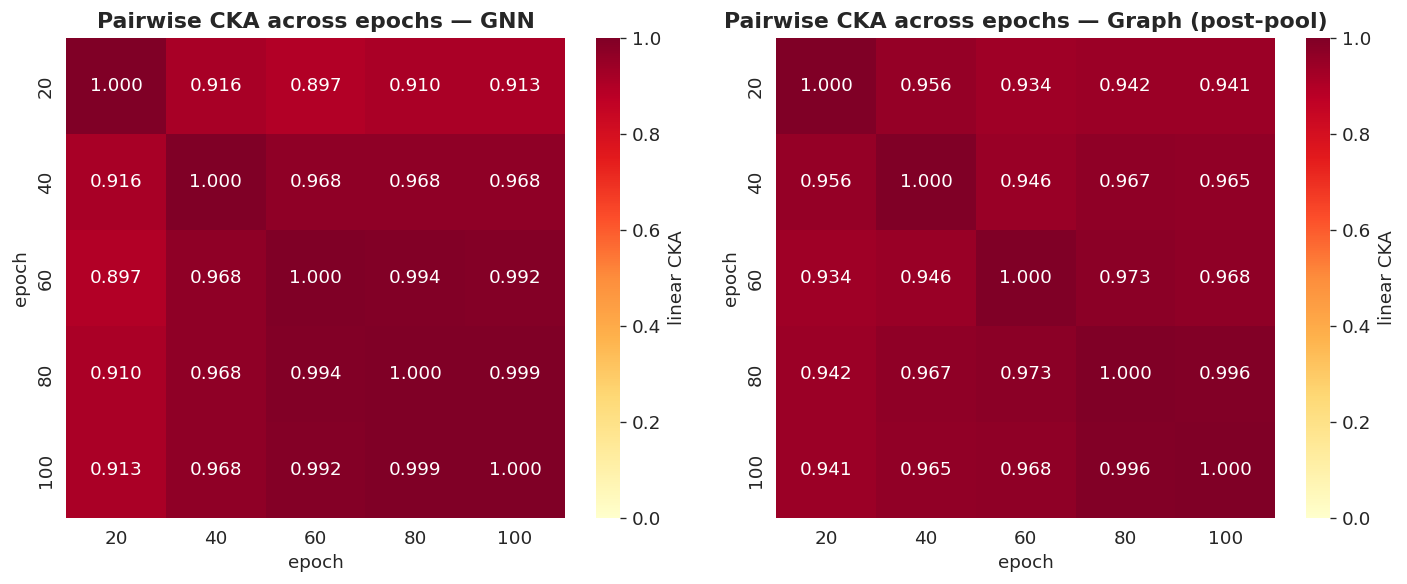

In [7]:
def linear_cka(X, Y):
    X = X - X.mean(0, keepdims=True)
    Y = Y - Y.mean(0, keepdims=True)
    num = np.linalg.norm(X.T @ Y, "fro") ** 2
    den = np.linalg.norm(X.T @ X, "fro") * np.linalg.norm(Y.T @ Y, "fro")
    return float(num / den) if den > 0 else 0.0


def pairwise_cka(embs):
    keys = sorted(embs.keys())
    M = np.zeros((len(keys), len(keys)))
    for i, a in enumerate(keys):
        for j, b in enumerate(keys):
            M[i, j] = linear_cka(embs[a], embs[b])
    return pd.DataFrame(M, index=keys, columns=keys)


fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (name, embs) in zip(axes, [("GNN", emb_gnn), ("Graph (post-pool)", emb_graph)]):
    if not embs:
        ax.set_visible(False); continue
    M = pairwise_cka(embs)
    sns.heatmap(M, annot=True, fmt=".3f", cmap="YlOrRd", vmin=0, vmax=1,
                ax=ax, cbar_kws={"label": "linear CKA"})
    ax.set_title(f"Pairwise CKA across epochs — {name}", fontweight="bold")
    ax.set_xlabel("epoch"); ax.set_ylabel("epoch")
fig.tight_layout(); plt.show()

,epoch,cka_gnn_vs_ref,cka_graph_vs_ref
0,20,1.000000,1.000000
1,40,0.915739,0.956017
2,60,0.896737,0.933690
3,80,0.910495,0.942274
4,100,0.913155,0.941476


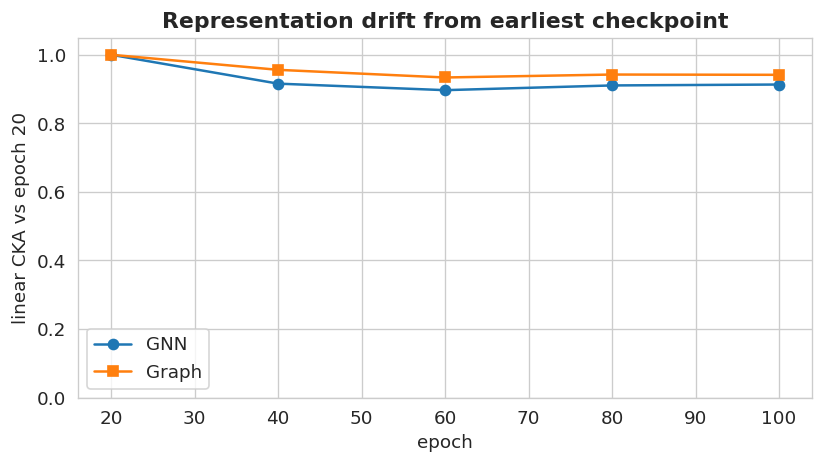

In [8]:
# Drift from the epoch-20 reference.
ref = min(emb_graph.keys())
rows = []
for e in sorted(emb_graph.keys()):
    rows.append({
        "epoch": e,
        "cka_gnn_vs_ref":   linear_cka(emb_gnn[ref], emb_gnn[e]),
        "cka_graph_vs_ref": linear_cka(emb_graph[ref], emb_graph[e]),
    })
drift = pd.DataFrame(rows)
display(drift)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(drift["epoch"], drift["cka_gnn_vs_ref"], "o-", label="GNN")
ax.plot(drift["epoch"], drift["cka_graph_vs_ref"], "s-", label="Graph")
ax.set_xlabel("epoch"); ax.set_ylabel(f"linear CKA vs epoch {ref}")
ax.set_title("Representation drift from earliest checkpoint", fontweight="bold")
ax.legend(); ax.set_ylim(0, 1.05); fig.tight_layout(); plt.show()

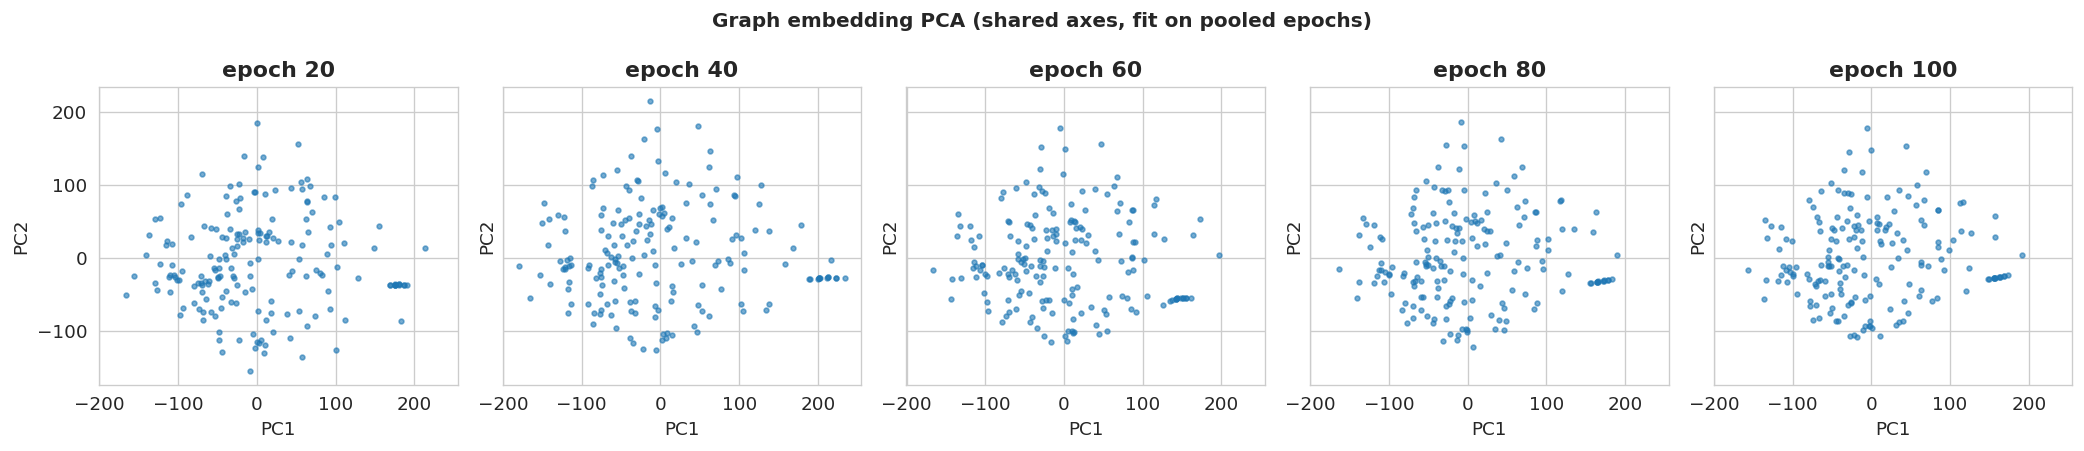

In [9]:
# PCA visualisation of graph embeddings per epoch (shared 2D axes).
from sklearn.decomposition import PCA

if emb_graph:
    keys = sorted(emb_graph.keys())
    pooled = np.vstack([emb_graph[k] for k in keys])
    pc = PCA(n_components=2).fit(pooled)
    fig, axes = plt.subplots(1, len(keys), figsize=(3.5 * len(keys), 3.8), sharex=True, sharey=True)
    if len(keys) == 1:
        axes = [axes]
    for ax, e in zip(axes, keys):
        z = pc.transform(emb_graph[e])
        ax.scatter(z[:, 0], z[:, 1], s=8, alpha=0.6)
        ax.set_title(f"epoch {e}", fontweight="bold")
        ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
    fig.suptitle("Graph embedding PCA (shared axes, fit on pooled epochs)",
                 fontsize=12, fontweight="bold")
    fig.tight_layout(); plt.show()

## 3. ADMET linear probing per epoch

For each epoch's backbone we freeze the encoder, extract graph embeddings for 5 representative
ADMET tasks (one per category), and fit a linear probe. This tracks how downstream transfer
evolves across pre-training epochs without the memory cost of all 22 tasks.

In [10]:
# 5 representative ADMET tasks (one per category) — matches probe/admet_linear.yaml.
from tdc.benchmark_group import admet_group

PROBE_TASKS = [
    'caco2_wang',       # Absorption  (regression,     spearman)
    'pgp_broccatelli',  # Distribution (classification, auroc) — actually Absorption but classification
    'cyp3a4_veith',     # Metabolism  (classification, auroc)
    'half_life_obach',  # Excretion   (regression,     spearman)
    'herg',             # Toxicity    (classification, auroc)
]

GROUP = admet_group(path="data/tdc/")

TASK_FRAMES = {}
for task in PROBE_TASKS:
    bench = GROUP.get(task)
    train_df = bench["train_val"]
    test_df = bench["test"]
    TASK_FRAMES[task] = {
        "train_smi": train_df["Drug"].tolist(),
        "train_y":   train_df["Y"].to_numpy(dtype=float),
        "test_smi":  test_df["Drug"].tolist(),
        "test_y":    test_df["Y"].to_numpy(dtype=float),
    }
    print(f"  {task:35s} train={len(train_df):5d}  test={len(test_df):4d}")
print(f"\nLoaded {len(TASK_FRAMES)} tasks (was 22 before)")

Found local copy...


  caco2_wang                          train=  728  test= 182
  pgp_broccatelli                     train=  973  test= 245
  cyp3a4_veith                        train= 9861  test=2467
  half_life_obach                     train=  532  test= 135
  herg                                train=  523  test= 132

Loaded 5 tasks (was 22 before)


In [11]:
# Featurize unique SMILES across the 5 probe tasks only.
all_smi = sorted({smi for d in TASK_FRAMES.values()
                  for smi in d["train_smi"] + d["test_smi"]})
print(f"unique SMILES across {len(PROBE_TASKS)} tasks: {len(all_smi)}")

SMI_TO_IDX = {}
admet_graphs = []
for smi in tqdm(all_smi, desc="featurize ADMET (5 tasks)"):
    mol = dm.to_mol(smi)
    if mol is None:
        continue
    try:
        g = mol_to_pyggraph(mol, on_error="raise", **FEATURIZATION)
    except Exception:
        continue
    SMI_TO_IDX[smi] = len(admet_graphs)
    admet_graphs.append(g)
print(f"featurized {len(admet_graphs)}/{len(all_smi)}")

unique SMILES across 5 tasks: 15301


featurize ADMET (5 tasks):   0%|          | 0/15301 [00:00<?, ?it/s]

featurized 15301/15301


In [12]:
# Linear-probe helpers.
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score, mean_absolute_error
from scipy.stats import spearmanr


def task_is_classification(task):
    metric, _ = TASK_METRICS[task]
    return metric in ("auroc", "auprc")


def probe_task(X_tr, y_tr, X_te, y_te, task):
    """Fit a linear probe and return the task's primary metric."""
    metric, direction = TASK_METRICS[task]
    scaler = StandardScaler().fit(X_tr)
    X_tr = scaler.transform(X_tr); X_te = scaler.transform(X_te)

    if task_is_classification(task):
        clf = LogisticRegression(max_iter=2000, C=1.0, class_weight="balanced")
        clf.fit(X_tr, y_tr.astype(int))
        prob = clf.predict_proba(X_te)[:, 1]
        if metric == "auroc":   return float(roc_auc_score(y_te, prob))
        if metric == "auprc":   return float(average_precision_score(y_te, prob))
    else:
        reg = Ridge(alpha=1.0)
        reg.fit(X_tr, y_tr)
        pred = reg.predict(X_te)
        if metric == "mae":       return float(mean_absolute_error(y_te, pred))
        if metric == "spearman":  return float(spearmanr(y_te, pred).correlation)
    return np.nan


def task_rows_from_embeddings(task, emb_mat):
    """Slice embedding matrix to a task's train/test rows using SMI_TO_IDX."""
    d = TASK_FRAMES[task]
    tr_idx = [SMI_TO_IDX[s] for s in d["train_smi"] if s in SMI_TO_IDX]
    te_idx = [SMI_TO_IDX[s] for s in d["test_smi"]  if s in SMI_TO_IDX]
    tr_y = np.asarray([y for s, y in zip(d["train_smi"], d["train_y"]) if s in SMI_TO_IDX])
    te_y = np.asarray([y for s, y in zip(d["test_smi"],  d["test_y"])  if s in SMI_TO_IDX])
    return emb_mat[tr_idx], tr_y, emb_mat[te_idx], te_y


In [13]:
# Extract embeddings once per epoch, then linear-probe the 5 representative tasks.
probe_rows = []
admet_emb_by_epoch = {}

for e in EPOCHS:
    p = CKPT_BY_EPOCH[e]
    if not p.exists():
        continue
    print(f"  epoch {e}: extracting embeddings…")
    model = load_backbone(p)
    _, gr = extract_embeddings(model, admet_graphs, batch_size=64, device=DEVICE)
    emb = gr.numpy()
    admet_emb_by_epoch[e] = emb
    del model
    if DEVICE.startswith("cuda"):
        torch.cuda.empty_cache()

    for task in PROBE_TASKS:
        X_tr, y_tr, X_te, y_te = task_rows_from_embeddings(task, emb)
        if len(X_tr) == 0 or len(X_te) == 0:
            continue
        try:
            val = probe_task(X_tr, y_tr, X_te, y_te, task)
        except Exception as ex:
            print(f"    probe failed on {task}: {ex}")
            val = np.nan
        probe_rows.append({
            "task": task,
            "category": TASK_CATEGORY.get(task, "?"),
            "metric": TASK_METRICS[task][0],
            "direction": TASK_METRICS[task][1],
            "pretrain_epoch": e,
            "value": val,
        })

res = pd.DataFrame(probe_rows)
print(f"collected {len(res)} task×epoch probe results")
res.head()

  epoch 20: extracting embeddings…
  epoch 40: extracting embeddings…
  epoch 60: extracting embeddings…
  epoch 80: extracting embeddings…
  epoch 100: extracting embeddings…
collected 25 task×epoch probe results


,task,category,metric,direction,pretrain_epoch,value
0,caco2_wang,Absorption,mae,lower,20,0.518967
1,pgp_broccatelli,Absorption,auroc,higher,20,0.865236
2,cyp3a4_veith,Metabolism,auprc,higher,20,0.828149
3,half_life_obach,Excretion,spearman,higher,20,0.205756
4,herg,Toxicity,auroc,higher,20,0.755081


pretrain_epoch,20,40,60,80,100
task,,,,,
caco2_wang,0.5190,0.7083,0.4553,0.5112,0.5493
pgp_broccatelli,0.8652,0.8855,0.8953,0.9022,0.8974
cyp3a4_veith,0.8281,0.8340,0.8184,0.8263,0.8244
half_life_obach,0.2058,0.0028,0.0073,0.0474,-0.0242
herg,0.7551,0.7722,0.8308,0.8054,0.8314


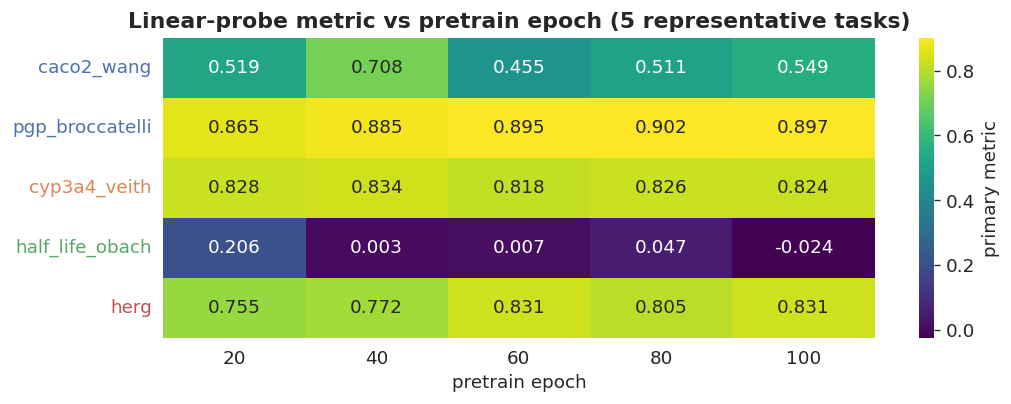

In [14]:
# Heatmap: 5 tasks × epoch
if not res.empty:
    pivot = (res.groupby(["task", "pretrain_epoch"])["value"].mean()
                .unstack("pretrain_epoch"))
    pivot = pivot.reindex(index=[t for t in PROBE_TASKS if t in pivot.index])
    pivot = pivot[sorted(pivot.columns)]
    display(pivot.round(4))

    fig, ax = plt.subplots(figsize=(1.2 * len(pivot.columns) + 3, 3.5))
    sns.heatmap(pivot, annot=True, fmt=".3f", cmap="viridis",
                cbar_kws={"label": "primary metric"}, ax=ax)
    ax.set_title("Linear-probe metric vs pretrain epoch (5 representative tasks)",
                 fontweight="bold")
    ax.set_xlabel("pretrain epoch"); ax.set_ylabel("")
    for lbl in ax.get_yticklabels():
        cat = TASK_CATEGORY.get(lbl.get_text(), "")
        lbl.set_color(CATEGORY_COLORS.get(cat, "black"))
    fig.tight_layout(); plt.show()

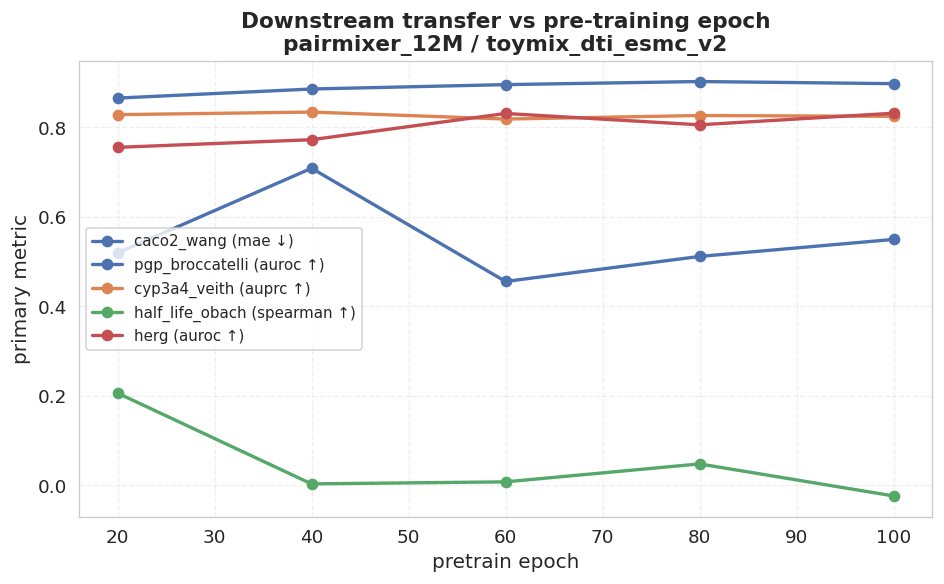

In [15]:
# Per-task line plot: metric vs epoch for each of the 5 tasks.
if not res.empty:
    fig, ax = plt.subplots(figsize=(8, 5))
    for task in PROBE_TASKS:
        sub = res[res["task"] == task]
        if sub.empty:
            continue
        g = sub.groupby("pretrain_epoch")["value"].mean().sort_index()
        cat = TASK_CATEGORY.get(task, "?")
        metric = TASK_METRICS[task][0]
        direction = TASK_METRICS[task][1]
        arrow = "↑" if direction == "higher" else "↓"
        ax.plot(g.index, g.values, "o-", linewidth=2, markersize=6,
                color=CATEGORY_COLORS.get(cat, "grey"),
                label=f"{task} ({metric} {arrow})")
    ax.set_xlabel("pretrain epoch", fontsize=12)
    ax.set_ylabel("primary metric", fontsize=12)
    ax.set_title("Downstream transfer vs pre-training epoch\n"
                 "pairmixer_12M / toymix_dti_esmc_v2",
                 fontsize=13, fontweight="bold")
    ax.legend(fontsize=9, loc="best", frameon=True)
    ax.grid(True, axis="both", ls="--", alpha=0.3)
    fig.tight_layout(); plt.show()

In [16]:
# Which epoch is best for each task?
if not res.empty:
    agg = (res.groupby(["task", "direction", "pretrain_epoch"])["value"].mean()
              .reset_index())
    wins = []
    for (task, direction), g in agg.groupby(["task", "direction"]):
        g = g.dropna(subset=["value"])
        if g.empty: continue
        best = g.loc[g["value"].idxmax() if direction == "higher" else g["value"].idxmin()]
        metric = TASK_METRICS[task][0]
        wins.append({
            "task": task,
            "category": TASK_CATEGORY.get(task, "?"),
            "metric": metric,
            "best_epoch": int(best["pretrain_epoch"]),
            "best_value": round(best["value"], 4),
        })
    wins_df = pd.DataFrame(wins).sort_values("task")
    display(wins_df)

,task,category,metric,best_epoch,best_value
0,caco2_wang,Absorption,mae,60,0.4553
1,cyp3a4_veith,Metabolism,auprc,40,0.8340
2,half_life_obach,Excretion,spearman,20,0.2058
3,herg,Toxicity,auroc,100,0.8314
4,pgp_broccatelli,Absorption,auroc,80,0.9022
